# Ridge Regression

**Full feature set**

Author: Pete King

We selected three models for this project, each of which approaches the regression problem of predicting future volatility differently.  The three models are:

 - Ridge Regressor:  A regressor that assumes all input features are independent and combine linearly; uses L2 norm regularization so that each input feature makes a nuanced contribution to the prediction.

 - Gradient Boosting Regressor:  An decision tree based estimator that assumes all input features are independent, but makes no assumptions about linear relationships between exogenous variables.

 - Long Short-Term Memory (LSTM):  A deep-learning model that assumes input features are dependent on each other over time, but makes no assumptions about linear relationships between exogenous variables.

In this notebook, we test the ability of the Ridge regressor to predict future near-term volatility in a rolling outlook.

Here, each sample of financial data that we introduce to the estimator is a feature vector (**x_t**) that contains the daily return for the ETF, its near-term historical volatility, and other market and financial conditions at time **t**.  The label (**y_t**) for each sample is the mid-term future volatility, which we computed earlier using a rolling window.

Because the Ridge regressor assumes a linear relationship between exogenous variables, we need to to scale our features so that each falls in the range (0, 1).  Otherwise, large-magnitude features will tend to dominate the regression estimate.

In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error
)
from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV
)
from sklearn.linear_model import Lasso, Ridge, ElasticNet

import data_prep as dp

DATA_FOLDER = 'data/train-val-test/'
TRAIN_DATA_FILE = DATA_FOLDER + 'train_ALL_DATA.csv'
VAL_DATA_FILE = DATA_FOLDER + 'val_ALL_DATA.csv'
TICKER = 'SPY'  # ETF selected for this analysis

## I. Import data

We have already split our data into training and validation sets.  We reserve the held-out validation set (val_df) to plot predictions for comparisons against other models, but we further divide the training set into cross-validation folds to take advantage of scikit-learn's [TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) function.  This gives us an easy way to apply scikit-learn's standard cross-validation (CV) methods for hyperparameter optimization while preserving chronological order between training and validation subsets within CV folds.

In [2]:
train_df = pd.read_csv(
    TRAIN_DATA_FILE,
    index_col='date',
    parse_dates=True
)
val_df = pd.read_csv(
    VAL_DATA_FILE,
    index_col='date',
    parse_dates=True
)

In [3]:
# Separate features from labels; include all features, including daily return
data_cols, _ = dp.get_X_y_cols(train_df, returns=True)
label_col = [TICKER + '_vol_target']
# Training set
X_train = train_df.dropna()[data_cols].astype(np.float32)
y_train = train_df.dropna()[label_col].astype(np.float32).values.reshape(-1,)
# Validation set
X_val = val_df.dropna()[data_cols].astype(np.float32)
y_val = val_df.dropna()[label_col].astype(np.float32).values.reshape(-1,)
# Define time series cross-validation split
ts_cv = TimeSeriesSplit(
    n_splits=3,
    test_size=252,
    gap=21
)
# Scale input features
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=data_cols
)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=data_cols)

## II. Define model, fit to data, and evaluate performance

Here we tune the hyperparameter 'alpha', which controls the degree of regularization in the model by scaling the L2-norm loss term in the linear regression.  A higher 'alpha' value provides greater regularization, which prevents overfitting but can lead to biased estimates.

In [4]:
# Define model, metrics, and Grid Search for hyperparameter tuning
estimator = Ridge()
metrics = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'MSE': 'neg_mean_squared_error',
    'r2': 'r2'
}
params = {
    'alpha': [0.01, 0.1, 1, 10]
}
reg = GridSearchCV(
    estimator,
    params,
    scoring=metrics,
    refit='MAE',
    cv=ts_cv
)

In [5]:
reg.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'MAE': 'neg_mean_absolute_error', 'MSE': 'neg_mean_squared_error', 'RMSE': 'neg_root_mean_squared_error', 'r2': 'r2'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'MAE'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...test_size=252)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation tim

### Visualize performance; Check evaluation metrics

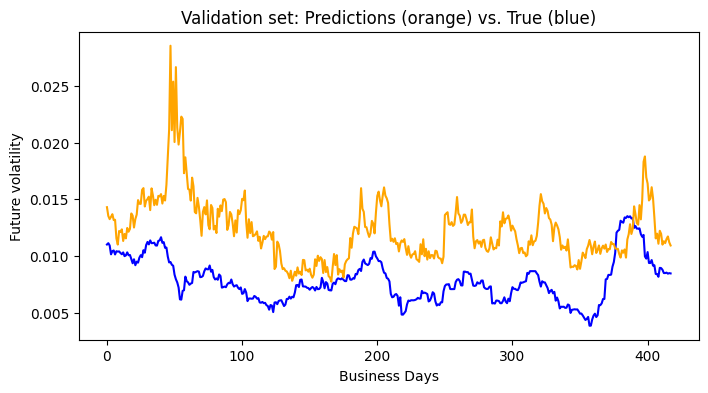

In [6]:
# Use the best estimator to make predictions on the validation set
best = reg.best_estimator_
preds = best.predict(X_val_scaled)
x = range(len(y_val))

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()
ax.set_title('Validation set: Predictions (orange) vs. True (blue)')
ax.set_ylabel('Future volatility')
ax.set_xlabel('Business Days')
ax.plot(x, y_val, color='blue')
ax.plot(x, preds, color='orange')

In [7]:
print(f'MAE: {mean_absolute_error(y_val, preds)}')
print(f'R2: {r2_score(y_val, preds)}')

MAE: 0.004525014199316502
R2: -6.154115676879883


From the plot we see that the model tends to follow the general future volatility trend fairly well (with some notable exceptions), but also tends to lag behind the asset's true volatility, and consistently overestimates future volatility.  Overestimation is not such a bad thing considering the business case: we want to ensure that an asset does not exceed an investor's risk tolerance.  However, we also want to maximize an investor's return, which makes overestimation of volatility less than ideal.

The negative value for R-squared would seem to indicate that our model explains very little about the actual underlying process, but since we are using multiple input features, we take this value with a grain of salt.  The visualization clearly shows that our model responds to actual asset volatility, albeit often in a delayed manner.

## III. Inspect model

Since we scaled all input features in the range (0, 1), we can look at the coefficients assigned to each feature to understand which ones are assigned the most weight (greatest coefficients) in the regression.

In [8]:
feature_importances = list(zip(best.feature_names_in_, best.coef_))
for feature, coef in sorted(feature_importances, key=lambda i: -np.abs(i[1])):
    print(f'{feature}: {coef:2.3f}')

^VXN: 0.008
^MOVE: 0.007
real_GDP_chg: -0.005
^VIX: 0.005
debt_interest_chg: -0.005
core_PCE_chg: 0.005
BIL_vol-h: -0.005
producer_price_index_chg: -0.004
BIL_ret-h: 0.004
consumer_price_index_chg: -0.004
CL=F_vol-h: -0.003
NG=F_vol-h: 0.003
XLV_vol-h: 0.003
XLK_vol-h: 0.003
three_month_yield_diff: -0.003
XLY_vol-h: 0.002
QQQ_vol-h: 0.002
XLP_vol-h: 0.002
XLF_ret-h: -0.002
^HSI_vol-h: 0.002
GC=F_vol-h: 0.002
average_duration_of_unemployment_chg: -0.002
^FTSE_ret: -0.002
nominal_GDP_chg: -0.002
XLRE_vol-h: 0.002
six_month_yield_diff: -0.002
IEF_vol-h: -0.002
core_PCI_chg: 0.002
SHY_vol-h: 0.002
BND_vol-h: -0.002
XLK_ret-h: -0.002
HYG_vol-h: -0.002
HG=F_vol-h: -0.002
XLI_ret-h: -0.002
IWM_vol-h: -0.002
GLD_vol-h: 0.001
XLE_ret-h: -0.001
SPY_vol-h: 0.001
one_year_yield_diff: -0.001
TIP_ret: -0.001
LQD_vol-h: -0.001
XLF_vol-h: -0.001
debt_to_GDP_chg: -0.001
XLB_ret-h: -0.001
TIP_vol-h: -0.001
LQD_ret-h: -0.001
one_month_yield_diff: -0.001
SPY_ret-h: -0.001
XLRE_ret-h: 0.001
XLU_vol-h: 0.00

These results show that while nearly all features make a nuanced contribution to the final estimate of future volatility, a few are much more important than the rest.  Not surprisingly, the two overall market volatility indexes (VIX and VXN) rank high on the list, as does the recent historical volatility of the asset itself (SPY_h-vol).

One final note, the VIX has been shown to consistently lag behind actual market volatility (ref this blog post). With the VIX ranking high on our list of important features for this model, it makes sense that we also see a lag in model's our visualized predictions.